In [41]:
import torch 
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [42]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_data = datasets.MNIST("data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_data,batch_size=64, shuffle=True)

test_data = datasets.MNIST("data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_data, batch_size=64, shuffle=True)

In [43]:
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.features(x)

model = MyModel()

In [72]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss() 
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.09)

def train(model, optimizer, criterion, dataloader):
    model.train()

    avg_loss = 0

    for x, y in train_loader:
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()

        avg_loss += loss.item()


    scheduler.step()
    print(f"Loss : {(avg_loss / len(dataloader)):.4f}")
    return avg_loss / len(dataloader)


train(model, optimizer, criterion, train_loader)


Loss : 0.0363


0.03626280241438539

In [61]:
def test(model, dataloader):
    model.eval()

    correct = 0

    with torch.no_grad():
        for x, y in test_loader:
            pred = model(x)
            predicted = pred.argmax(dim=1)
            correct += (predicted == y).sum().item()

        correct /= len(dataloader.dataset)
        print(f"Accuracy : {(100*correct):>0.1f}%")
    
    return 100*correct

test(model, test_loader)

Accuracy : 97.1%


97.09

Epoch 1
Loss : 0.0260
Accuracy : 98.0%
Epoch 2
Loss : 0.0278
Accuracy : 97.9%
Epoch 3
Loss : 0.0225
Accuracy : 97.9%
Epoch 4
Loss : 0.0250
Accuracy : 98.0%
Epoch 5
Loss : 0.0197
Accuracy : 98.0%
Epoch 6
Loss : 0.0198
Accuracy : 97.9%
Epoch 7
Loss : 0.0180
Accuracy : 98.3%
Epoch 8
Loss : 0.0180
Accuracy : 98.4%
Epoch 9
Loss : 0.0167
Accuracy : 98.0%
Epoch 10
Loss : 0.0060
Accuracy : 98.5%


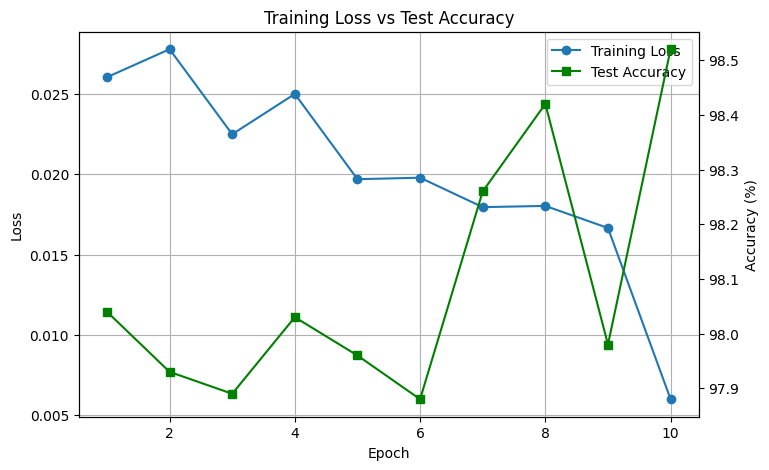

In [73]:
train_losses = []
test_accuracies = []
epochs = 10
for epoch in range(epochs):
    print(f"Epoch {epoch+1}")
    train_loss = train(model, optimizer, criterion, train_loader)
    test_acc = test(model, test_loader)
    train_losses.append(train_loss)
    test_accuracies.append(test_acc)

epoch_plot = range(1, epochs+1)
fig, ax1 = plt.subplots(figsize=(8, 5))

#Training Loss
ax1.plot(epoch_plot, train_losses, marker='o', label='Training Loss')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True)

#Test Accuracy
ax2 = ax1.twinx()
ax2.plot(epoch_plot, test_accuracies, marker='s', color='green', label='Test Accuracy')
ax2.set_ylabel("Accuracy (%)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.title("Training Loss vs Test Accuracy")
plt.show()

In [74]:
torch.save(model.state_dict(), "model_task2.pt")

In [75]:
model = MyModel()
model.load_state_dict(torch.load("model_task2.pt"))
model.eval()

MyModel(
  (features): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=512, bias=True)
    (4): ReLU()
    (5): Linear(in_features=512, out_features=10, bias=True)
  )
)

# How to Improve Accuracy Further

Shifting from Multiple Layers to a full Convolutional Neural Network containing layers like Dropout(), BatchNorm(), Conv2d() etc. will boost accuracy further

Also using more epochs will yield better accuracy until it saturates (around 15-20 epochs)